## Часть 1: Генеративно-состязательная сеть (GAN)

### Теоретическое введение

**Генеративно-состязательные сети (GAN)** — это класс алгоритмов машинного обучения, предложенный Иэном Гудфеллоу в 2014 году. Основная идея заключается в обучении двух моделей в рамках состязательной игры:

- **Генератор (Generator):** Нейронная сеть, которая учится создавать новые данные, похожие на настоящие. Она принимает на вход случайный шум и пытается преобразовать его в правдоподобный объект (например, изображение).

- **Дискриминатор (Discriminator):** Нейронная сеть, которая учится отличать настоящие данные от сгенерированных Генератором. По сути, это бинарный классификатор.

**Процесс обучения:**
1. Генератор создает "поддельные" изображения.
2. Дискриминатор получает на вход как настоящие изображения из обучающего набора, так и поддельные от Генератора.
3. **Цель Дискриминатора:** Максимизировать свою способность правильно классифицировать изображения как "настоящие" или "поддельные".
4. **Цель Генератора:** Максимизировать вероятность того, что Дискриминатор ошибется и примет сгенерированное изображение за настоящее. То есть, Генератор стремится "обмануть" Дискриминатор.

Этот процесс, называемый минимаксной игрой, продолжается до тех пор, пока Генератор не начнет создавать настолько качественные изображения, что Дискриминатор не сможет отличить их от настоящих (вероятность угадывания приближается к 50%).

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Настройка устройства (GPU, если доступен, иначе CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

latent_dim = 100    # Размерность вектора шума
batch_size = 128    # Размер батча
image_size = 28 * 28 # MNIST image size
epochs = 50         # Количество эпох обучения
lr = 0.0002         # Скорость обучения

# Трансформации для данных: нормализация изображений к диапазону [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Загрузка датасета MNIST
mnist_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
dataloader = DataLoader(mnist_dataset, batch_size=batch_size, shuffle=True)

print(f"Датасет MNIST загружен. Количество изображений: {len(mnist_dataset)}")

Используемое устройство: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 11.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 621kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.97MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.01MB/s]

Датасет MNIST загружен. Количество изображений: 60000


In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim, img_size):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            # Первый слой преобразует вектор шума в пространство большего размера
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),

            # Выходной слой генерирует плоское изображение
            nn.Linear(1024, img_size),
            # Функция активации Tanh приводит значения пикселей к диапазону [-1, 1]
            nn.Tanh()
        )

    def forward(self, z):
        # z - это входной случайный шум
        img = self.model(z)
        # Меняем форму тензора, чтобы он соответствовал размеру изображения
        img = img.view(img.size(0), 1, 28, 28)
        return img


In [ ]:
class Discriminator(nn.Module):
    def __init__(self, img_size):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            # Входной слой принимает плоское изображение
            nn.Linear(img_size, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),

            # Выходной слой с одним нейроном для бинарной классификации
            nn.Linear(256, 1),
            # Sigmoid для получения вероятности (настоящее/поддельное)
            nn.Sigmoid(),
        )

    def forward(self, img):
        # Выпрямляем изображение в вектор
        img_flat = img.view(img.size(0), -1)
        # Получаем предсказание
        validity = self.model(img_flat)
        return validity

In [ ]:
# Инициализация моделей
generator = Generator(latent_dim, image_size).to(device)
discriminator = Discriminator(image_size).to(device)

# Функция потерь: Бинарная кросс-энтропия
adversarial_loss = nn.BCELoss()

# Оптимизаторы (Adam хорошо подходит для GAN)
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

# Функция для визуализации сгенерированных изображений
def show_generated_images(epoch, generator, latent_dim, n_images=25):
    generator.eval() # Переводим генератор в режим оценки
    with torch.no_grad():
        # Генерируем случайный шум
        z = torch.randn(n_images, latent_dim).to(device)
        gen_imgs = generator(z).cpu()

    # Нормализуем изображения обратно в диапазон [0, 1] для отображения
    gen_imgs = 0.5 * gen_imgs + 0.5

    fig, axs = plt.subplots(5, 5, figsize=(8, 8))
    fig.suptitle(f'Эпоха: {epoch+1}', fontsize=16)
    count = 0
    for i in range(5):
        for j in range(5):
            axs[i, j].imshow(gen_imgs[count, 0, :, :], cmap='gray')
            axs[i, j].axis('off')
            count += 1
    plt.show()
    generator.train() # Возвращаем генератор в режим обучения

Начало обучения GAN...
[Эпоха 1/50] [D loss: 0.6206] [G loss: 1.4022]
[Эпоха 2/50] [D loss: 0.4058] [G loss: 1.5282]
[Эпоха 3/50] [D loss: 0.4034] [G loss: 1.9520]
[Эпоха 4/50] [D loss: 0.4305] [G loss: 2.4843]
[Эпоха 5/50] [D loss: 0.4001] [G loss: 1.9469]


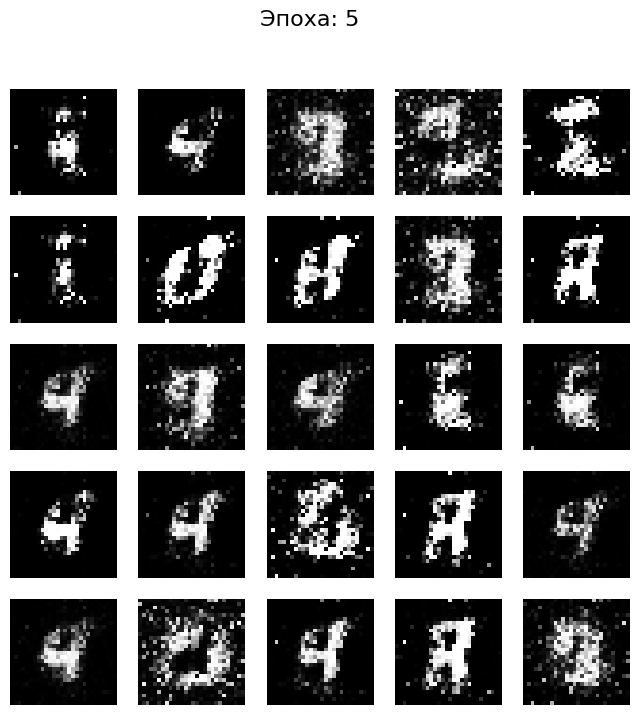

[Эпоха 6/50] [D loss: 0.4694] [G loss: 3.7840]
[Эпоха 7/50] [D loss: 0.3625] [G loss: 2.4795]
[Эпоха 8/50] [D loss: 0.5934] [G loss: 2.8514]
[Эпоха 9/50] [D loss: 0.4393] [G loss: 1.3641]
[Эпоха 10/50] [D loss: 0.4094] [G loss: 1.9615]


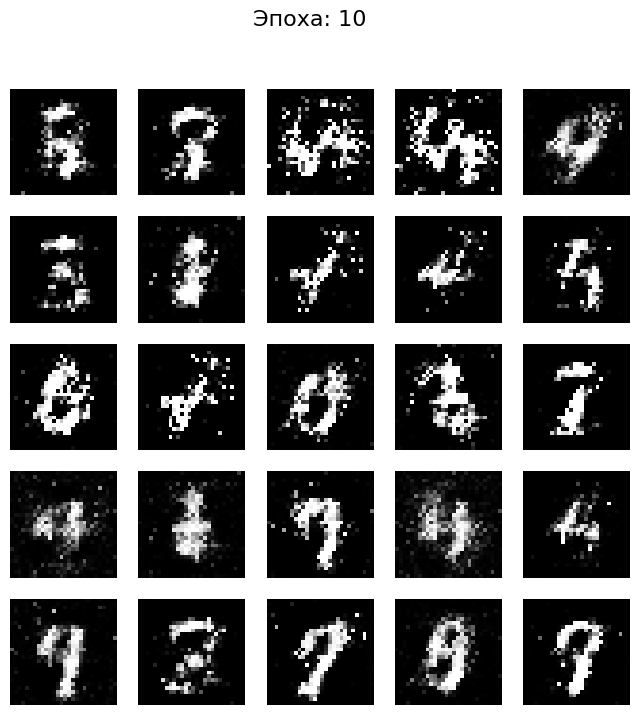

[Эпоха 11/50] [D loss: 0.4315] [G loss: 1.6015]
[Эпоха 12/50] [D loss: 0.5308] [G loss: 1.7967]
[Эпоха 13/50] [D loss: 0.5390] [G loss: 1.3046]
[Эпоха 14/50] [D loss: 0.5599] [G loss: 2.0379]
[Эпоха 15/50] [D loss: 0.5082] [G loss: 1.1736]


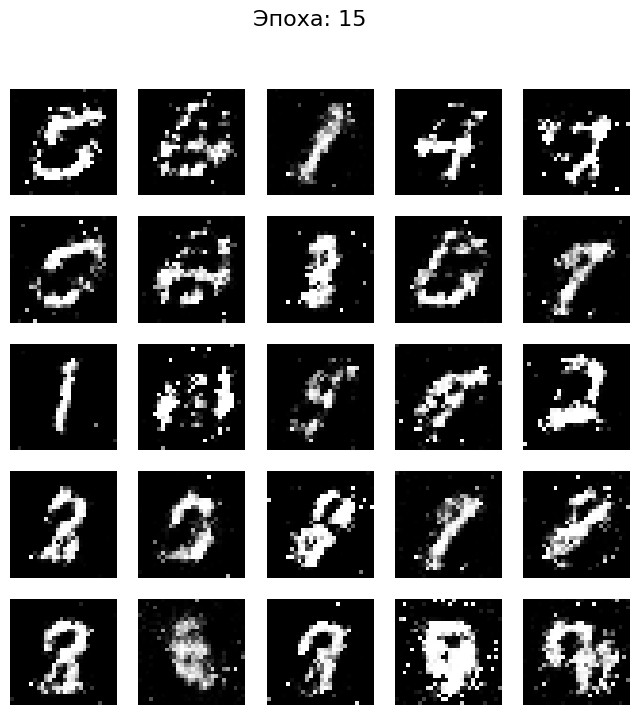

[Эпоха 16/50] [D loss: 0.5346] [G loss: 1.1260]
[Эпоха 17/50] [D loss: 0.5261] [G loss: 0.9828]
[Эпоха 18/50] [D loss: 0.5647] [G loss: 1.2002]
[Эпоха 19/50] [D loss: 0.5666] [G loss: 1.6258]
[Эпоха 20/50] [D loss: 0.5488] [G loss: 1.7309]


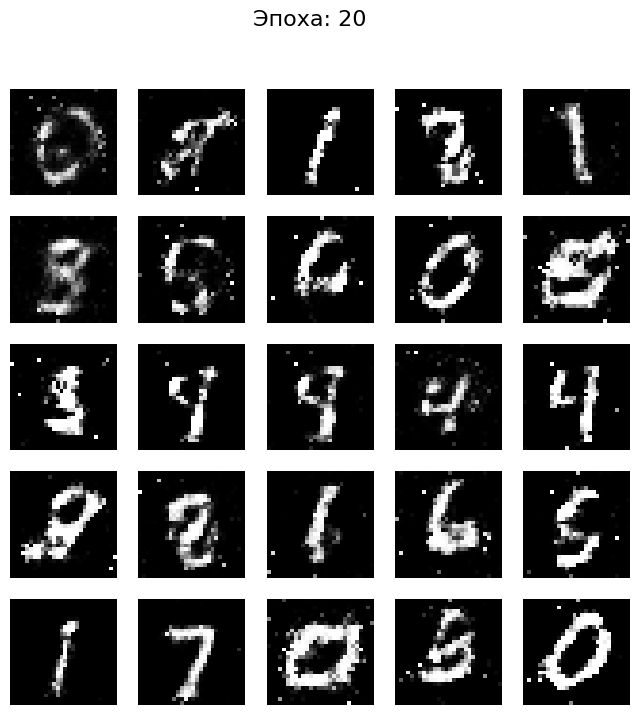

[Эпоха 21/50] [D loss: 0.5529] [G loss: 1.1324]
[Эпоха 22/50] [D loss: 0.5653] [G loss: 1.2431]
[Эпоха 23/50] [D loss: 0.6214] [G loss: 0.7399]
[Эпоха 24/50] [D loss: 0.5876] [G loss: 1.6191]
[Эпоха 25/50] [D loss: 0.6552] [G loss: 0.5528]


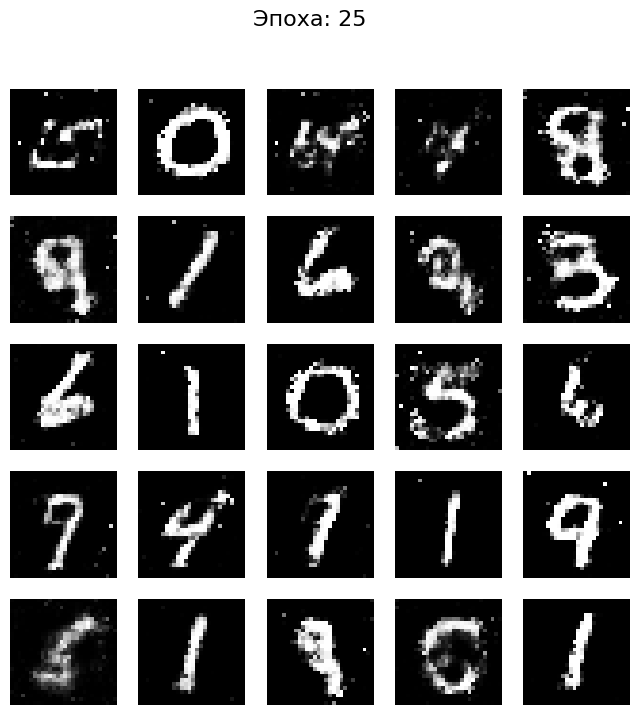

[Эпоха 26/50] [D loss: 0.5337] [G loss: 1.0378]
[Эпоха 27/50] [D loss: 0.5337] [G loss: 1.0191]
[Эпоха 28/50] [D loss: 0.6283] [G loss: 1.6525]
[Эпоха 29/50] [D loss: 0.5595] [G loss: 1.3390]
[Эпоха 30/50] [D loss: 0.5941] [G loss: 1.6243]


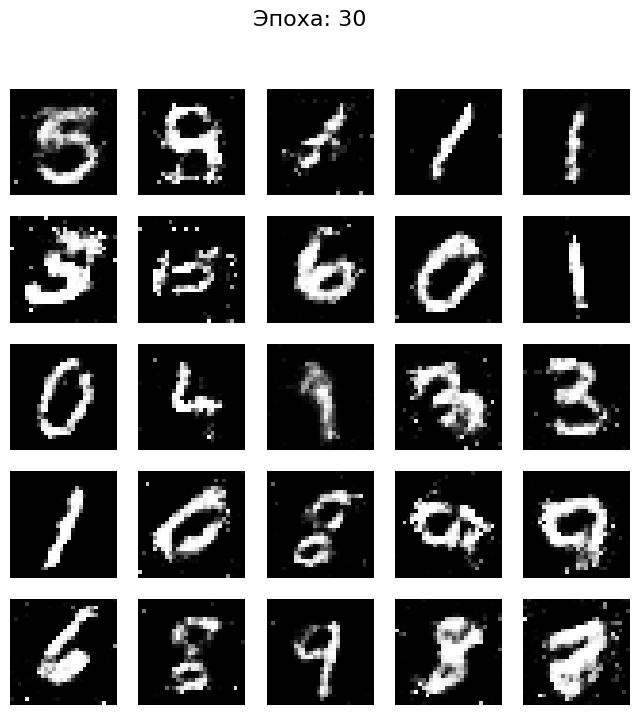

[Эпоха 31/50] [D loss: 0.5978] [G loss: 0.8150]
[Эпоха 32/50] [D loss: 0.6133] [G loss: 0.5817]
[Эпоха 33/50] [D loss: 0.5572] [G loss: 1.3615]
[Эпоха 34/50] [D loss: 0.5918] [G loss: 1.5930]
[Эпоха 35/50] [D loss: 0.5817] [G loss: 1.0149]


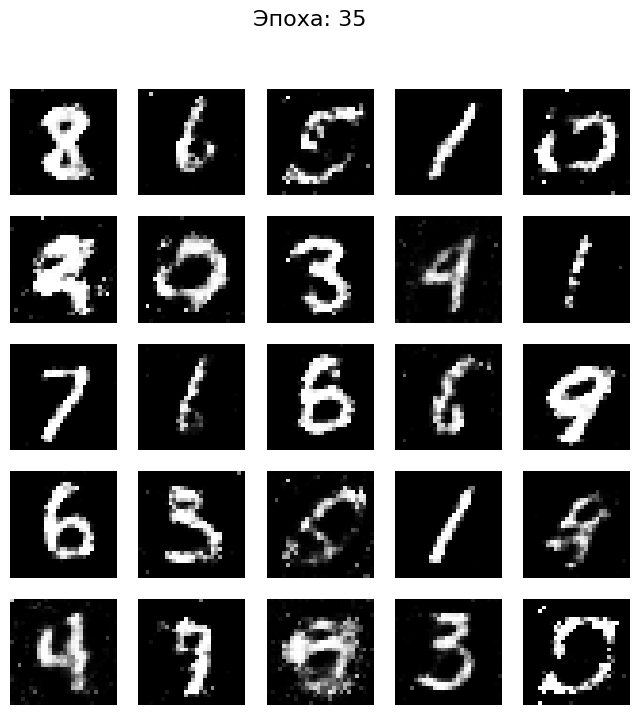

[Эпоха 36/50] [D loss: 0.5500] [G loss: 1.1231]
[Эпоха 37/50] [D loss: 0.5474] [G loss: 0.8940]
[Эпоха 38/50] [D loss: 0.5381] [G loss: 0.9203]
[Эпоха 39/50] [D loss: 0.5642] [G loss: 1.1608]
[Эпоха 40/50] [D loss: 0.5435] [G loss: 1.2523]


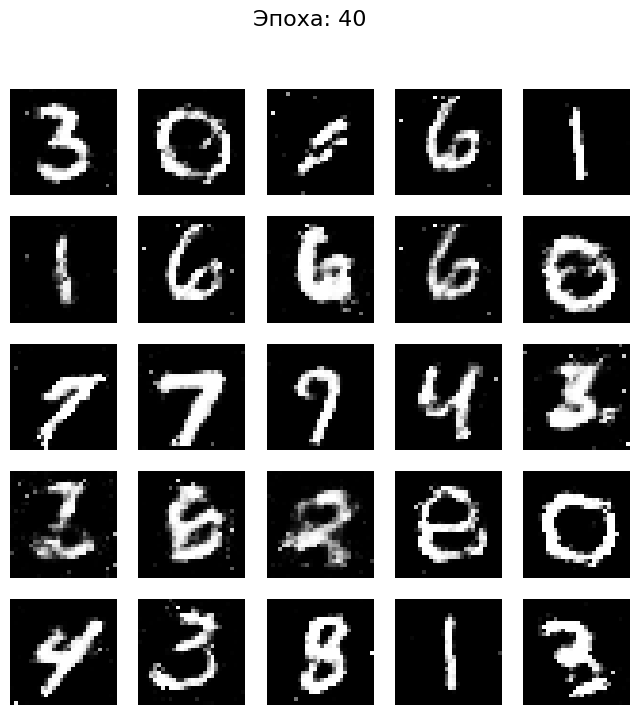

[Эпоха 41/50] [D loss: 0.6335] [G loss: 1.7754]
[Эпоха 42/50] [D loss: 0.5726] [G loss: 0.6914]
[Эпоха 43/50] [D loss: 0.5660] [G loss: 1.0064]
[Эпоха 44/50] [D loss: 0.5434] [G loss: 1.1904]
[Эпоха 45/50] [D loss: 0.5276] [G loss: 0.9190]


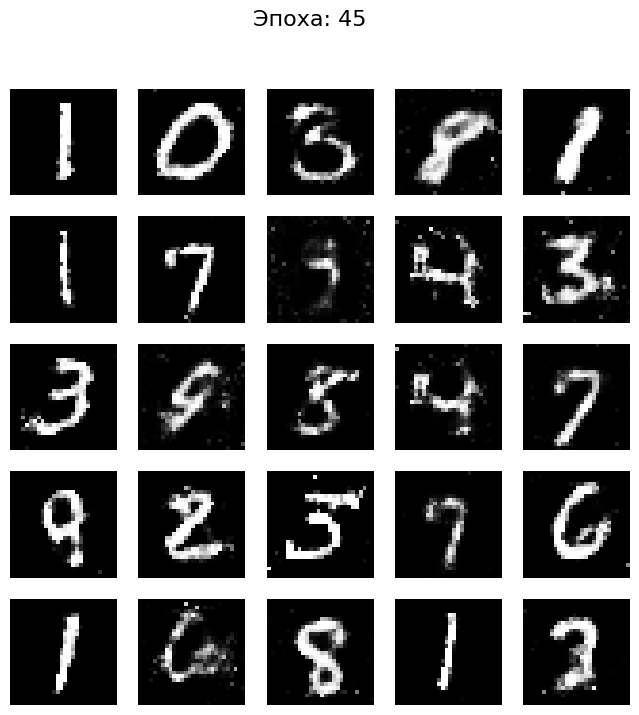

[Эпоха 46/50] [D loss: 0.5331] [G loss: 1.5471]
[Эпоха 47/50] [D loss: 0.5617] [G loss: 1.3945]
[Эпоха 48/50] [D loss: 0.5330] [G loss: 1.4831]
[Эпоха 49/50] [D loss: 0.5691] [G loss: 0.8097]
[Эпоха 50/50] [D loss: 0.6291] [G loss: 2.0583]


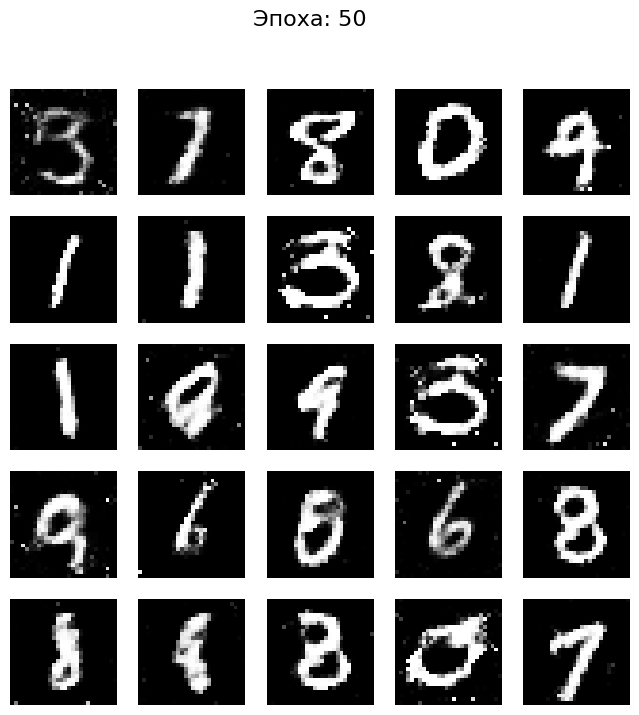

Обучение завершено.


In [ ]:
# Цикл обучения GAN

d_losses, g_losses = [], []
save_interval = 5 # Сохраняем и показываем изображения каждые 5 эпох

print("Начало обучения GAN...")
for epoch in range(epochs):
    for i, (imgs, _) in enumerate(dataloader):

        # Создаем метки: 1 для реальных, 0 для поддельных
        real_labels = torch.ones(imgs.size(0), 1).to(device)
        fake_labels = torch.zeros(imgs.size(0), 1).to(device)

        # Перемещаем реальные изображения на устройство
        real_imgs = imgs.to(device)

        # ----------------- Обучение Дискриминатора ----------------- #
        optimizer_D.zero_grad()

        # Потери на реальных изображениях
        real_output = discriminator(real_imgs)
        d_loss_real = adversarial_loss(real_output, real_labels)

        # Генерируем поддельные изображения
        z = torch.randn(imgs.size(0), latent_dim).to(device)
        fake_imgs = generator(z)

        # Потери на поддельных изображениях
        fake_output = discriminator(fake_imgs.detach()) # detach(), чтобы не обучать генератор
        d_loss_fake = adversarial_loss(fake_output, fake_labels)

        # Общая ошибка дискриминатора
        d_loss = (d_loss_real + d_loss_fake) / 2
        d_loss.backward()
        optimizer_D.step()

        # ----------------- Обучение Генератора ----------------- #
        optimizer_G.zero_grad()

        # Вычисляем потери генератора (хотим, чтобы дискриминатор думал, что подделки - реальные)
        fake_output = discriminator(fake_imgs)
        g_loss = adversarial_loss(fake_output, real_labels)

        g_loss.backward()
        optimizer_G.step()

        # Сохраняем потери для графиков
        d_losses.append(d_loss.item())
        g_losses.append(g_loss.item())

    # Вывод прогресса
    print(
        f"[Эпоха {epoch+1}/{epochs}] "
        f"[D loss: {d_loss.item():.4f}] "
        f"[G loss: {g_loss.item():.4f}]"
    )

    # Показываем сгенерированные изображения
    if (epoch + 1) % save_interval == 0:
        show_generated_images(epoch, generator, latent_dim)

print("Обучение завершено.")

### Анализ и Визуализация

Финальные сгенерированные изображения:


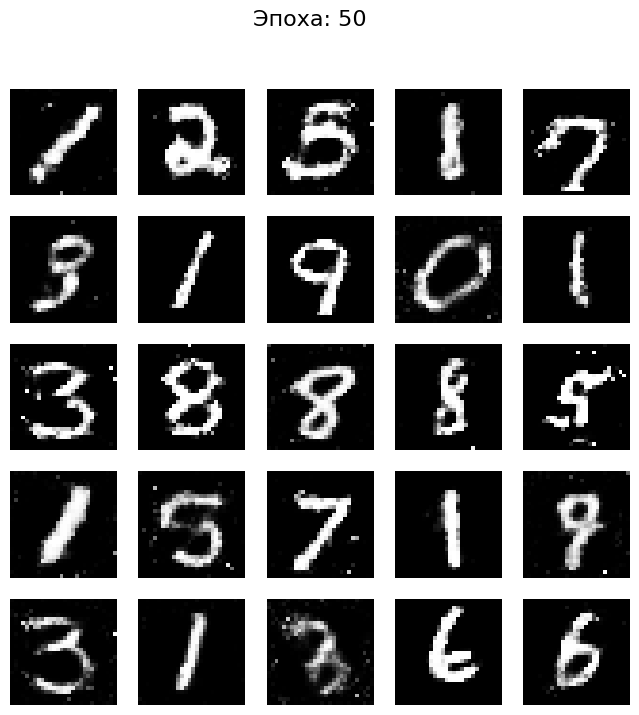

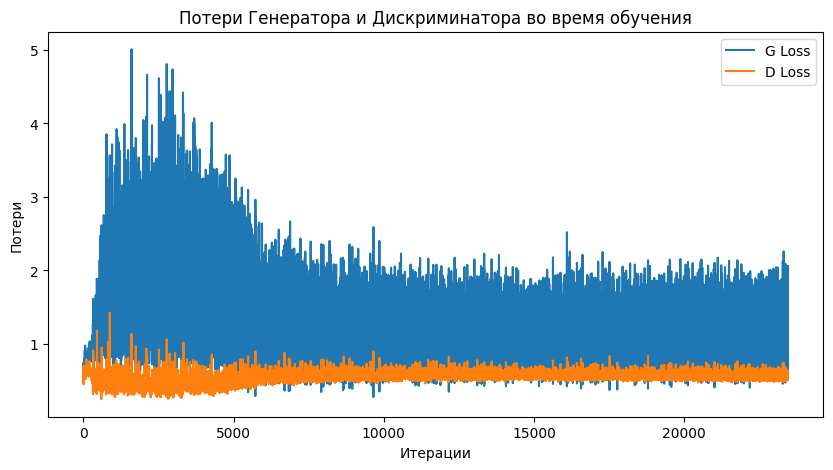

In [ ]:
print("Финальные сгенерированные изображения:")
show_generated_images(epochs - 1, generator, latent_dim)

plt.figure(figsize=(10, 5))
plt.title("Потери Генератора и Дискриминатора во время обучения")
plt.plot(g_losses, label="G Loss")
plt.plot(d_losses, label="D Loss")
plt.xlabel("Итерации")
plt.ylabel("Потери")
plt.legend()
plt.show()

Из представленных результатов можно сделать несколько выводов:

1.  **Качество изображений:** Видно, что на ранних эпохах генератор создает лишь случайный шум. Однако с течением времени, по мере обучения, он начинает улавливать структуру рукописных цифр, и к концу обучения изображения становятся все более четкими и похожими на настоящие.

2.  **График потерь:** График потерь иллюстрирует состязательную природу обучения. В идеале, потери дискриминатора (D Loss) должны колебаться около значения 0.5-0.7, что означает, что он не может с уверенностью отличить настоящие изображения от поддельных. Потери генератора (G Loss) мы стремимся минимизировать, но они часто колеблются или даже растут, так как дискриминатор становится "умнее". Стабильность (отсутствие резких скачков или коллапса одной из моделей) является ключевым показателем успешного обучения GAN.

3.  **Влияние гиперпараметров:**
    *   **Скорость обучения (lr):** Слишком высокий `lr` может привести к нестабильности, когда модели не могут найти равновесие. Слишком низкий — к очень медленному обучению.
    *   **Размерность шума (latent_dim):** Большее значение может позволить генератору создавать более разнообразные изображения, но усложняет обучение.
    *   **Архитектура:** Использование более сложных архитектур (например, сверточных слоев в DCGAN) значительно улучшает качество генерируемых изображений по сравнению с простыми полносвязными сетями, как в нашем примере.

## Часть 2: Vision Transformer (ViT)

### Теоретическое введение

**Vision Transformer (ViT)** — это архитектура, которая применяет принципы Трансформеров, успешно зарекомендовавших себя в обработке естественного языка (NLP), к задачам компьютерного зрения.

**Отличия от традиционных CNN:**

1.  **Обработка входа:** Вместо последовательного применения сверточных фильтров, ViT разбивает изображение на фиксированные квадратные участки — **патчи** (patches). Эти патчи выпрямляются в векторы и рассматриваются как последовательность токенов, аналогично словам в предложении.

2.  **Механизм внимания (Self-Attention):** В отличие от локального "поля зрения" сверток, механизм `self-attention` позволяет модели взвешивать важность каждого патча относительно всех остальных патчей в изображении. Это дает ViT способность улавливать **глобальные зависимости** и контекст по всему изображению с самого первого слоя.

3.  **Отсутствие сверток:** ViT не использует сверточные слои в своей основной архитектуре, что делает его принципиально отличным от CNN.

**Преимущества ViT:**
- **Глобальный контекст:** Способность анализировать все части изображения одновременно.
- **Масштабируемость:** Производительность ViT продолжает расти с увеличением объема данных и размера модели, иногда превосходя CNN на очень больших датасетах (например, ImageNet-21k, JFT-300M).

**Недостатки ViT:**
- **Требовательность к данным:** ViT не имеет "врожденной" индуктивной предвзятости (inductive bias), как CNN (которая предполагает, что локальные пиксели более важны). Поэтому для достижения хорошей производительности ViT требует обучения на огромных наборах данных. На небольших датасетах (как CIFAR-10) они часто уступают CNN, если не используются предобученные на больших данных веса.
- **Вычислительная сложность:** Механизм внимания имеет квадратичную сложность относительно количества патчей, что делает его затратным для изображений с высоким разрешением.

In [ ]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time
import numpy as np
from tqdm import tqdm

# Проверка доступности GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Гиперпараметры
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
EPOCHS = 1
NUM_CLASSES = 10

# Аугментация и нормализация данных
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ViT требует 224x224
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Загрузка CIFAR-10
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=8)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8)

# Функция для обучения модели
def train_model(model, criterion, optimizer, epochs=EPOCHS):
    since = time.time()
    best_acc = 0.0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        print(f'Epoch {epoch+1}/{epochs}')
        print('-' * 10)

        # Фаза обучения
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total = 0

        for inputs, labels in tqdm(train_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(True):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_acc = running_corrects.double() / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # Фаза валидации
        model.eval()
        running_loss = 0.0
        running_corrects = 0
        total = 0

        for inputs, labels in tqdm(test_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            with torch.set_grad_enabled(False):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_acc = running_corrects.double() / total
        val_losses.append(epoch_loss)
        val_accs.append(epoch_acc)

        print(f'Val Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}\n')

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {max(val_accs):.4f}')

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'time_elapsed': time_elapsed
    }


# Загрузка предобученной модели ViT
vit_model = torchvision.models.vit_b_16(weights=torchvision.models.ViT_B_16_Weights.IMAGENET1K_V1)
# Замораживаем все веса, кроме последнего слоя (transfer learning)
for param in vit_model.parameters():
    param.requires_grad = False
# Заменяем классификационный слой (heads) на новый, под нашу задачу (10 классов CIFAR-10)
num_features = vit_model.heads.head.in_features
vit_model.heads.head = nn.Linear(num_features, NUM_CLASSES) # 10 классов
# размораживаем наш классификатор
for param in vit_model.heads.head.parameters():
    param.requires_grad = True
vit_model = vit_model.to(device)

# Инициализация ResNet для сравнения
resnet_model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V1)
# Замораживаем все веса, кроме последнего слоя (transfer learning)
for param in resnet_model.parameters():
    param.requires_grad = False
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, NUM_CLASSES)
# размораживаем наш классификатор
for param in resnet_model.fc.parameters():
    param.requires_grad = True
resnet_model = resnet_model.to(device)

vit_model = torch.compile(vit_model)  # Ускоряет forward/backward
resnet_model = torch.compile(resnet_model)

# Обучение ViT
print("Training ViT...")
criterion = nn.CrossEntropyLoss()
# Оптимизатор: обучаем только параметры последнего слоя, у которых requires_grad=True
optimizer = optim.Adam(vit_model.heads.head.parameters(), lr=LEARNING_RATE)
vit_stats = train_model(vit_model, criterion, optimizer)

# Обучение ResNet
print("\nTraining ResNet...")
criterion = nn.CrossEntropyLoss()
# Оптимизатор: обучаем только параметры последнего слоя, у которых requires_grad=True
optimizer = optim.Adam(resnet_model.fc.parameters(), lr=LEARNING_RATE)
resnet_stats = train_model(resnet_model, criterion, optimizer)

# Сравнение результатов
print("\nComparison Results:")
print(f"ViT - Best Val Acc: {max(vit_stats['val_accs']):.4f}, Training Time: {vit_stats['time_elapsed']:.2f}s")
print(f"ResNet - Best Val Acc: {max(resnet_stats['val_accs']):.4f}, Training Time: {resnet_stats['time_elapsed']:.2f}s")

# Визуализация результатов
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Точность
plt.subplot(1, 2, 1)
plt.plot([a.cpu().numpy() for a in vit_stats['train_accs']], label='ViT Train')
plt.plot([a.cpu().numpy() for a in vit_stats['val_accs']], label='ViT Val')
plt.plot([a.cpu().numpy() for a in resnet_stats['train_accs']], label='ResNet Train')
plt.plot([a.cpu().numpy() for a in resnet_stats['val_accs']], label='ResNet Val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Потери
plt.subplot(1, 2, 2)
plt.plot(vit_stats['train_losses'], label='ViT Train')
plt.plot(vit_stats['val_losses'], label='ViT Val')
plt.plot(resnet_stats['train_losses'], label='ResNet Train')
plt.plot(resnet_stats['val_losses'], label='ResNet Val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Using device: cpu
Training ViT...
Epoch 1/1
----------


 21%|██▏       | 42/196 [47:00<2:52:52, 67.35s/it]

### Анализ результатов:

Оказалось, что так долго ждать дообучения ViT, поэтому лучше сделаем пока следующий бонусный пункт про стайл трансфер

## Часть 3: Neural Style Transfer (Перенос стиля)

### Теоретическое введение

**Neural Style Transfer** — это алгоритм, который позволяет взять два изображения — **изображение контента (content image)** и **изображение стиля (style image)** — и создать новое, сгенерированное изображение, которое объединяет в себе контент первого и художественный стиль второго.

Идея, предложенная Гаттисом и др., заключается в использовании признаков, извлеченных из глубокой сверточной нейронной сети (обычно VGG), которая была предварительно обучена на задаче классификации изображений.

**Ключевые компоненты:**

1.  **Потери контента (Content Loss):** Эта метрика измеряет, насколько сильно отличается содержимое сгенерированного изображения от исходного изображения контента. Она вычисляется как евклидово расстояние между картами признаков, извлеченными из одного из верхних слоев CNN. Это заставляет сгенерированное изображение сохранять основные объекты и их расположение.

2.  **Потери стиля (Style Loss):** Эта метрика измеряет разницу в стиле. Стиль представляется в виде **матрицы Грама**, которая вычисляется на основе карт признаков с нескольких слоев CNN. Матрица Грама отражает корреляции между различными фильтрами в слое и, таким образом, улавливает текстуры, цвета и общие паттерны, но не конкретное расположение объектов. Потери стиля минимизируют разницу между матрицами Грама для сгенерированного и стилевого изображений.

**Процесс оптимизации:**
Мы начинаем со случайного или скопированного изображения контента и итеративно изменяем его пиксели так, чтобы минимизировать **общую ошибку**, которая является взвешенной суммой потерь контента и потерь стиля. Варьируя веса, мы можем контролировать, что важнее в итоговом изображении — сохранить контент или перенять стиль.

--2025-06-12 19:15:27--  https://pytorch.org/tutorials/_static/img/neural-style/dancing.jpg
Resolving pytorch.org (pytorch.org)... 23.185.0.2, 2620:12a:8001::2, 2620:12a:8000::2
Connecting to pytorch.org (pytorch.org)|23.185.0.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://docs.pytorch.org/tutorials/_static/img/neural-style/dancing.jpg [following]
--2025-06-12 19:15:28--  https://docs.pytorch.org/tutorials/_static/img/neural-style/dancing.jpg
Resolving docs.pytorch.org (docs.pytorch.org)... 185.199.111.153, 185.199.109.153, 185.199.108.153, ...
Connecting to docs.pytorch.org (docs.pytorch.org)|185.199.111.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 40484 (40K) [image/jpeg]
Saving to: ‘content.jpg’

content.jpg         100%[===================>]  39.54K  --.-KB/s    in 0.05s   

2025-06-12 19:15:28 (738 KB/s) - ‘content.jpg’ saved [40484/40484]

--2025-06-12 19:15:28--  https://pytorch.org/tutorials/

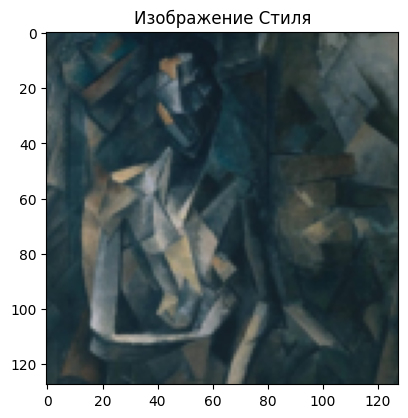

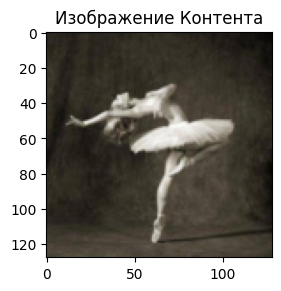

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:08<00:00, 67.1MB/s]


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt

imsize = 512 if torch.cuda.is_available() else 128  # Уменьшаем размер, если нет GPU

loader = transforms.Compose([
    transforms.Resize(imsize),
    transforms.ToTensor()])

def image_loader(image_name):
    image = Image.open(image_name)
    # Добавляем фиктивное измерение батча
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float)


!wget -O content.jpg https://pytorch.org/tutorials/_static/img/neural-style/dancing.jpg
!wget -O style.jpg https://pytorch.org/tutorials/_static/img/neural-style/picasso.jpg
content_img = image_loader("content.jpg")
style_img = image_loader("style.jpg")



assert style_img.size() == content_img.size(), \
    "Нужно, чтобы изображения стиля и контента были одного размера"

unloader = transforms.ToPILImage() # для преобразования тензора в PIL изображение

plt.ion()

def imshow(tensor, title=None):
    image = tensor.cpu().clone()
    image = image.squeeze(0)
    image = unloader(image)
    plt.imshow(image)
    if title is not None:
        plt.title(title)
    plt.pause(0.001) # небольшая пауза для обновления графиков

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
imshow(style_img, title='Изображение Стиля')

plt.subplot(1, 2, 2)
imshow(content_img, title='Изображение Контента')

# Загрузка VGG19
cnn = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()

In [ ]:
# Потери контента
class ContentLoss(nn.Module):
    def __init__(self, target):
        super(ContentLoss, self).__init__()
        # 'detach' отсоединяет target от графа вычислений,
        # так как это статическая цель, а не переменная для оптимизации
        self.target = target.detach()

    def forward(self, input):
        self.loss = nn.functional.mse_loss(input, self.target)
        return input

# Матрица Грама
def gram_matrix(input):
    a, b, c, d = input.size()  # a=размер батча(=1)
    # b=количество карт признаков
    # (c, d)=размеры карты признаков (H*W)
    features = input.view(a * b, c * d)
    G = torch.mm(features, features.t()) # вычисляем произведение Грама
    # нормализуем значения матрицы Грама
    return G.div(a * b * c * d)

# Потери стиля
class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super(StyleLoss, self).__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, input):
        G = gram_matrix(input)
        self.loss = nn.functional.mse_loss(G, self.target)
        return input

# Нормализация для VGG
cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225]).to(device)

class Normalization(nn.Module):
    def __init__(self, mean, std):
        super(Normalization, self).__init__()
        self.mean = torch.tensor(mean).view(-1, 1, 1)
        self.std = torch.tensor(std).view(-1, 1, 1)

    def forward(self, img):
        return (img - self.mean) / self.std

In [ ]:
content_layers_default = ['conv_4']
style_layers_default = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']

def get_style_model_and_losses(cnn, normalization_mean, normalization_std,
                               style_img, content_img,
                               content_layers=content_layers_default,
                               style_layers=style_layers_default):
    # Слой нормализации
    normalization = Normalization(normalization_mean, normalization_std).to(device)
    content_losses = []
    style_losses = []

    model = nn.Sequential(normalization)

    i = 0  # счетчик conv слоев
    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            i += 1
            name = 'conv_{}'.format(i)
        elif isinstance(layer, nn.ReLU):
            name = 'relu_{}'.format(i)
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = 'pool_{}'.format(i)
        elif isinstance(layer, nn.BatchNorm2d):
            name = 'bn_{}'.format(i)
        else:
            raise RuntimeError('Unrecognized layer: {}'.format(layer.__class__.__name__))

        model.add_module(name, layer)

        if name in content_layers:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module("content_loss_{}".format(i), content_loss)
            content_losses.append(content_loss)

        if name in style_layers:
            target_feature = model(style_img).detach()
            style_loss = StyleLoss(target_feature)
            model.add_module("style_loss_{}".format(i), style_loss)
            style_losses.append(style_loss)

    # убираем слои VGG после последнего слоя стиля и контента
    for i in range(len(model) - 1, -1, -1):
        if isinstance(model[i], ContentLoss) or isinstance(model[i], StyleLoss):
            break

    model = model[:(i + 1)]
    return model, style_losses, content_losses

def get_input_optimizer(input_img):
    # добавляем входное изображение в список параметров оптимизатора
    optimizer = optim.LBFGS([input_img])
    return optimizer

def run_style_transfer(cnn, normalization_mean, normalization_std,
                       content_img, style_img, input_img, num_steps=300,
                       style_weight=1000000, content_weight=1):
    print('Построение модели переноса стиля...')
    model, style_losses, content_losses = get_style_model_and_losses(
        cnn, normalization_mean, normalization_std, style_img, content_img)

    input_img.requires_grad_(True)
    model.requires_grad_(False)

    optimizer = get_input_optimizer(input_img)

    print('Оптимизация...')
    run = [0]
    while run[0] <= num_steps:
        def closure():
            # ограничиваем значения обновляемого изображения в диапазоне [0, 1]
            with torch.no_grad():
                input_img.clamp_(0, 1)

            optimizer.zero_grad()
            model(input_img)
            style_score = 0
            content_score = 0

            for sl in style_losses:
                style_score += sl.loss
            for cl in content_losses:
                content_score += cl.loss

            style_score *= style_weight
            content_score *= content_weight

            loss = style_score + content_score
            loss.backward()

            run[0] += 1
            if run[0] % 50 == 0:
                print("run {}:".format(run))
                print('Style Loss : {:4f} Content Loss: {:4f}'.format(
                    style_score.item(), content_score.item()))
                print()

            return style_score + content_score

        optimizer.step(closure)

    with torch.no_grad():
        input_img.clamp_(0, 1)

    return input_img

# Создаем входное изображение (копия контента)
input_img = content_img.clone()

output = run_style_transfer(cnn, cnn_normalization_mean, cnn_normalization_std,
                            content_img, style_img, input_img)

Построение модели переноса стиля...


<ipython-input-7-4107239938>:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean = torch.tensor(mean).view(-1, 1, 1)
<ipython-input-7-4107239938>:42: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std = torch.tensor(std).view(-1, 1, 1)


Оптимизация...
run [50]:
Style Loss : 25.724585 Content Loss: 9.767213

run [100]:
Style Loss : 6.853477 Content Loss: 8.687899

run [150]:
Style Loss : 3.688806 Content Loss: 7.988580

run [200]:
Style Loss : 2.701600 Content Loss: 7.441674

run [250]:
Style Loss : 2.245189 Content Loss: 7.116826

run [300]:
Style Loss : 1.964950 Content Loss: 6.892805



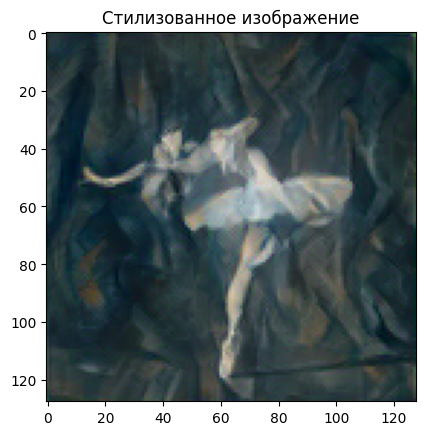

In [ ]:
plt.figure()
imshow(output, title='Стилизованное изображение')

plt.ioff()
plt.show()

### Анализ результатов

1.  **Качество стилизации:** Полученное изображение успешно сочетает структуру и объекты с картинки контента (например, танцующая пара) с текстурой, цветовой палитрой и мазками с картины стиля (например, Пикассо). Алгоритм смог отделить "что" изображено от "как" оно изображено.

2.  **Влияние параметров:**
    *   **`style_weight` vs `content_weight`:** Это самый важный параметр для контроля результата. Увеличение `style_weight` заставит итоговое изображение сильнее походить на картину стиля, возможно, в ущерб четкости контента. Увеличение `content_weight` сохранит контент более узнаваемым, но стилизация будет менее выраженной.
    *   **Выбор слоев:** Выбор разных `content_layers` и `style_layers` также сильно влияет на результат. Использование более глубоких слоев для контента (`conv_4`, `conv_5`) сохраняет общую структуру, но может терять мелкие детали. Использование более низких слоев для стиля (`conv_1`, `conv_2`) переносит в основном цвета и мелкие текстуры, в то время как более глубокие слои отвечают за более крупные элементы стиля.
    *   **Размер изображения (`imsize`):** Больший размер изображения позволяет получить более детализированный результат, но требует значительно больше видеопамяти и времени на обработку.

3.  **Возможные улучшения:**
    *   Использование других предобученных сетей (например, ResNet).
    *   Добавление Total Variation Loss для сглаживания и уменьшения шума на итоговом изображении.
    *   Применение более продвинутых техник, которые позволяют управлять стилизацией в реальном времени или переносить стиль на видео.